# Random Forest: PD vs CN Classification

Following the logistic regression baseline (75% subject-level accuracy with mRMR),  
we now try Random Forest, which can capture non-linear feature interactions.

---

In [1]:
CYMO_CSV   = '../ParkCeleb/ann.cymo_parkceleb.csv'
META_CSV   = '../ParkCeleb/cymo_parkceleb_metadata.csv'
MRMR_FEATS = './mrmr_selected_features.csv'
OLD_FEATS  = './cymo_final_selected_features.csv'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             RocCurveDisplay)

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10,
                     'axes.titlesize': 11, 'axes.titleweight': 'bold'})
print('Imports OK')

Imports OK


## 1 — Load data & split (identical to logistic regression notebook)

In [3]:
# ============================================================
# 1.1  Load & merge
# ============================================================
cymo = pd.read_csv(CYMO_CSV)
meta = pd.read_csv(META_CSV)

tid_col = 'TID' if 'TID' in cymo.columns else cymo.columns[0]
meta_tid = 'TID' if 'TID' in meta.columns else meta.columns[0]
all_feat_cols = [c for c in cymo.columns if c != tid_col]

df = cymo.merge(meta[[meta_tid, 'group', 'subject']].drop_duplicates(),
                left_on=tid_col, right_on=meta_tid, how='inner')
df['label'] = (df['group'] == 'PD').astype(int)

for col in all_feat_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Load feature lists
mrmr_features = pd.read_csv(MRMR_FEATS)['feature'].tolist()
old_features  = pd.read_csv(OLD_FEATS)['feature'].tolist()
mrmr_features = [f for f in mrmr_features if f in df.columns]
old_features  = [f for f in old_features if f in df.columns]

print(f'Data: {len(df)} utterances, {df["subject"].nunique()} subjects')
print(f'mRMR features: {len(mrmr_features)}   Old features: {len(old_features)}')

Data: 149546 utterances, 100 subjects
mRMR features: 25   Old features: 25


In [4]:
# ============================================================
# 1.2  Subject-level stratified split (same seed as LR notebook)
# ============================================================
np.random.seed(42)

subject_labels = df.groupby('subject')['label'].first().reset_index()
cn_subjs = subject_labels[subject_labels['label']==0]['subject'].values.copy()
pd_subjs = subject_labels[subject_labels['label']==1]['subject'].values.copy()
np.random.shuffle(cn_subjs)
np.random.shuffle(pd_subjs)

def split_70_20_10(subjects):
    n = len(subjects)
    n_tr = int(n * 0.7)
    n_va = int(n * 0.2)
    return subjects[:n_tr], subjects[n_tr:n_tr+n_va], subjects[n_tr+n_va:]

cn_tr, cn_va, cn_te = split_70_20_10(cn_subjs)
pd_tr, pd_va, pd_te = split_70_20_10(pd_subjs)

train_subjects = np.concatenate([cn_tr, pd_tr])
val_subjects   = np.concatenate([cn_va, pd_va])
test_subjects  = np.concatenate([cn_te, pd_te])

train_df = df[df['subject'].isin(train_subjects)].copy()
val_df   = df[df['subject'].isin(val_subjects)].copy()
test_df  = df[df['subject'].isin(test_subjects)].copy()

for name, sdf in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    cn_s = sdf[sdf['label']==0]['subject'].nunique()
    pd_s = sdf[sdf['label']==1]['subject'].nunique()
    print(f'{name:>5s}: {len(sdf):>6d} utterances  |  {cn_s} CN + {pd_s} PD subjects')

Train: 106467 utterances  |  42 CN + 28 PD subjects
  Val:  26881 utterances  |  12 CN + 8 PD subjects
 Test:  16198 utterances  |  6 CN + 4 PD subjects


---
## 2 — Hyperparameter tuning on validation set

Random Forest has more knobs than logistic regression.  
We'll do a grid search using the **training set** and evaluate on the **validation set**  
to pick the best hyperparameters, then do the final evaluation on the **test set**.

In [5]:
# ============================================================
# 2.  Prepare data helper
# ============================================================

def prepare(train_df, val_df, test_df, features):
    """Fill NaN with training median, standardise."""
    medians = train_df[features].median()
    
    X_tr = train_df[features].fillna(medians).values
    X_va = val_df[features].fillna(medians).values
    X_te = test_df[features].fillna(medians).values
    
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_va = scaler.transform(X_va)
    X_te = scaler.transform(X_te)
    
    y_tr = train_df['label'].values
    y_va = val_df['label'].values
    y_te = test_df['label'].values
    
    return X_tr, X_va, X_te, y_tr, y_va, y_te, scaler


def subject_eval(sdf, features, model, scaler):
    """Subject-level majority vote evaluation."""
    X = scaler.transform(sdf[features].fillna(sdf[features].median()).values)
    sdf = sdf.copy()
    sdf['pred'] = model.predict(X)
    sdf['prob'] = model.predict_proba(X)[:, 1]
    
    subj = sdf.groupby('subject').agg(
        true_label=('label', 'first'),
        group=('group', 'first'),
        mean_prob=('prob', 'mean'),
        vote_pred=('pred', lambda x: int(x.mean() >= 0.5)),
        n_utt=('pred', 'count'),
        pct_pd=('pred', 'mean'),
    ).reset_index()
    
    acc = accuracy_score(subj['true_label'], subj['vote_pred'])
    f1  = f1_score(subj['true_label'], subj['vote_pred'])
    auc = roc_auc_score(subj['true_label'], subj['mean_prob'])
    sens = recall_score(subj['true_label'], subj['vote_pred'])
    spec = recall_score(subj['true_label'], subj['vote_pred'], pos_label=0)
    
    return subj, {'acc': acc, 'f1': f1, 'auc': auc, 'sens': sens, 'spec': spec}

In [6]:
# ============================================================
# 2.1  Grid search for Random Forest (mRMR features)
# ============================================================
X_tr_m, X_va_m, X_te_m, y_tr, y_va, y_te, scaler_m = \
    prepare(train_df, val_df, test_df, mrmr_features)

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [5, 10, 20, None],
    'min_samples_leaf': [3, 5, 10],
}

print('Grid search for Random Forest (mRMR features)...')
print(f'Trying {len(param_grid["n_estimators"]) * len(param_grid["max_depth"]) * len(param_grid["min_samples_leaf"])} combinations\n')

best_val_auc = 0
best_params = {}
grid_results = []

for n_est in param_grid['n_estimators']:
    for depth in param_grid['max_depth']:
        for min_leaf in param_grid['min_samples_leaf']:
            rf = RandomForestClassifier(
                n_estimators=n_est,
                max_depth=depth,
                min_samples_leaf=min_leaf,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1,
            )
            rf.fit(X_tr_m, y_tr)
            
            # Evaluate on validation set at subject level
            _, val_metrics = subject_eval(val_df, mrmr_features, rf, scaler_m)
            
            grid_results.append({
                'n_estimators': n_est,
                'max_depth': depth,
                'min_samples_leaf': min_leaf,
                'val_acc': val_metrics['acc'],
                'val_f1': val_metrics['f1'],
                'val_auc': val_metrics['auc'],
            })
            
            if val_metrics['auc'] > best_val_auc:
                best_val_auc = val_metrics['auc']
                best_params = {'n_estimators': n_est, 'max_depth': depth,
                               'min_samples_leaf': min_leaf}

grid_df = pd.DataFrame(grid_results).sort_values('val_auc', ascending=False)

print('Top 10 configurations by validation AUC:')
print(f'{"Trees":>7s} {"Depth":>7s} {"MinLeaf":>8s} {"Val Acc":>9s} {"Val F1":>8s} {"Val AUC":>9s}')
print('─' * 52)
for _, row in grid_df.head(10).iterrows():
    d = str(row['max_depth']) if row['max_depth'] else 'None'
    print(f'{row["n_estimators"]:>7.0f} {d:>7s} {row["min_samples_leaf"]:>8.0f} '
          f'{row["val_acc"]:>9.3f} {row["val_f1"]:>8.3f} {row["val_auc"]:>9.3f}')

print(f'\nBest params: {best_params}  (Val AUC = {best_val_auc:.3f})')

Grid search for Random Forest (mRMR features)...
Trying 36 combinations

Top 10 configurations by validation AUC:
  Trees   Depth  MinLeaf   Val Acc   Val F1   Val AUC
────────────────────────────────────────────────────
    200     nan        3     0.800    0.667     0.750
    500     nan        3     0.800    0.667     0.740
    100     nan        3     0.800    0.667     0.740
    200     nan        5     0.750    0.615     0.740
    500     nan        5     0.750    0.615     0.740
    500    20.0        3     0.800    0.750     0.729
    500    20.0       10     0.800    0.750     0.729
    100    10.0        3     0.350    0.519     0.729
    500    20.0        5     0.800    0.750     0.729
    100    10.0        5     0.350    0.519     0.729

Best params: {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 3}  (Val AUC = 0.750)


In [7]:
# ============================================================
# 2.2  Train final models with best params
# ============================================================

# --- mRMR model ---
rf_mrmr = RandomForestClassifier(
    **best_params,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf_mrmr.fit(X_tr_m, y_tr)

# --- Old features: same grid search ---
X_tr_o, X_va_o, X_te_o, _, _, _, scaler_o = \
    prepare(train_df, val_df, test_df, old_features)

best_val_auc_old = 0
best_params_old = {}

for n_est in param_grid['n_estimators']:
    for depth in param_grid['max_depth']:
        for min_leaf in param_grid['min_samples_leaf']:
            rf_tmp = RandomForestClassifier(
                n_estimators=n_est, max_depth=depth,
                min_samples_leaf=min_leaf,
                class_weight='balanced', random_state=42, n_jobs=-1,
            )
            rf_tmp.fit(X_tr_o, y_tr)
            _, vm = subject_eval(val_df, old_features, rf_tmp, scaler_o)
            if vm['auc'] > best_val_auc_old:
                best_val_auc_old = vm['auc']
                best_params_old = {'n_estimators': n_est, 'max_depth': depth,
                                   'min_samples_leaf': min_leaf}

rf_old = RandomForestClassifier(
    **best_params_old,
    class_weight='balanced', random_state=42, n_jobs=-1,
)
rf_old.fit(X_tr_o, y_tr)

print(f'mRMR best params: {best_params}')
print(f'Old   best params: {best_params_old}')

mRMR best params: {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 3}
Old   best params: {'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 5}


In [8]:
# ============================================================
# 2.3  Save models
# ============================================================
joblib.dump({'model': rf_mrmr, 'scaler': scaler_m, 'features': mrmr_features,
             'params': best_params}, 'rf_mrmr.joblib')
joblib.dump({'model': rf_old, 'scaler': scaler_o, 'features': old_features,
             'params': best_params_old}, 'rf_old.joblib')
print('Saved: rf_mrmr.joblib, rf_old.joblib')

Saved: rf_mrmr.joblib, rf_old.joblib


---
## 3 — Evaluation

In [9]:
# ============================================================
# 3.1  Subject-level results
# ============================================================
print('SUBJECT-LEVEL RESULTS (majority vote)')
print('=' * 75)
print(f'{"":<8s} {"mRMR RF":>25s}     {"Old RF":>25s}')
print(f'{"":<8s} {"Acc / F1 / AUC / Sens / Spec":>25s}     {"Acc / F1 / AUC / Sens / Spec":>25s}')
print('─' * 75)

all_results = {}  # store for later comparison

for split_name, sdf in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    _, rm = subject_eval(sdf, mrmr_features, rf_mrmr, scaler_m)
    _, ro = subject_eval(sdf, old_features, rf_old, scaler_o)
    all_results[f'RF_mRMR_{split_name}'] = rm
    all_results[f'RF_Old_{split_name}'] = ro
    
    print(f'{split_name:<8s} '
          f'{rm["acc"]:.3f} / {rm["f1"]:.3f} / {rm["auc"]:.3f} / {rm["sens"]:.3f} / {rm["spec"]:.3f}     '
          f'{ro["acc"]:.3f} / {ro["f1"]:.3f} / {ro["auc"]:.3f} / {ro["sens"]:.3f} / {ro["spec"]:.3f}')

SUBJECT-LEVEL RESULTS (majority vote)
                           mRMR RF                        Old RF
         Acc / F1 / AUC / Sens / Spec     Acc / F1 / AUC / Sens / Spec
───────────────────────────────────────────────────────────────────────────
Train    0.929 / 0.912 / 0.976 / 0.929 / 0.929     1.000 / 1.000 / 1.000 / 1.000 / 1.000
Val      0.800 / 0.667 / 0.750 / 0.500 / 1.000     0.800 / 0.667 / 0.750 / 0.500 / 1.000
Test     0.800 / 0.750 / 0.792 / 0.750 / 0.833     0.700 / 0.571 / 0.750 / 0.500 / 0.833


In [10]:
# ============================================================
# 3.2  Per-subject detail (test set, mRMR RF)
# ============================================================
subj_detail, _ = subject_eval(test_df, mrmr_features, rf_mrmr, scaler_m)

print('Per-subject detail (Test set, mRMR Random Forest):')
print(f'{"Subject":<12s} {"True":>6s} {"Pred":>6s} {"OK":>4s} {"P(PD)":>7s} {"Utts":>6s} {"%PD":>5s}')
print('─' * 50)
for _, row in subj_detail.sort_values('subject').iterrows():
    true = 'PD' if row['true_label'] == 1 else 'CN'
    pred = 'PD' if row['vote_pred'] == 1 else 'CN'
    ok = '✓' if true == pred else '✗'
    print(f'{row["subject"]:<12s} {true:>6s} {pred:>6s} {ok:>4s} '
          f'{row["mean_prob"]:>7.3f} {row["n_utt"]:>6.0f} {row["pct_pd"]:>4.0%}')

Per-subject detail (Test set, mRMR Random Forest):
Subject        True   Pred   OK   P(PD)   Utts   %PD
──────────────────────────────────────────────────
cn_08            CN     CN    ✓   0.483    563  39%
cn_15            CN     CN    ✓   0.502   2348  46%
cn_29            CN     PD    ✗   0.563   2088  67%
cn_39            CN     CN    ✓   0.482   1020  36%
cn_43            CN     CN    ✓   0.096    571   0%
cn_52            CN     CN    ✓   0.326    810  25%
pd_07            PD     PD    ✓   0.519   2348  52%
pd_08            PD     PD    ✓   0.541    804  56%
pd_14            PD     CN    ✗   0.492   4809  38%
pd_35            PD     PD    ✓   0.526    837  57%


---
## 4 — Compare all four models

Logistic Regression (mRMR & Old) vs Random Forest (mRMR & Old)

In [11]:
# ============================================================
# 4.1  Also run LR for fair comparison (same split)
# ============================================================

# mRMR LR
lr_mrmr = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0, random_state=42)
lr_mrmr.fit(X_tr_m, y_tr)

# Old LR
lr_old = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0, random_state=42)
lr_old.fit(X_tr_o, y_tr)

# Collect all subject-level test results
models = [
    ('LR + Old',   lr_old,  old_features,  scaler_o),
    ('LR + mRMR',  lr_mrmr, mrmr_features, scaler_m),
    ('RF + Old',   rf_old,  old_features,  scaler_o),
    ('RF + mRMR',  rf_mrmr, mrmr_features, scaler_m),
]

comparison = []
test_preds = {}  # for ROC curves

for model_name, model, features, scaler in models:
    for split_name, sdf in [('Val', val_df), ('Test', test_df)]:
        subj, metrics = subject_eval(sdf, features, model, scaler)
        comparison.append({
            'Model': model_name,
            'Split': split_name,
            **metrics,
        })
        if split_name == 'Test':
            test_preds[model_name] = subj

comp_df = pd.DataFrame(comparison)

print('ALL MODELS — SUBJECT-LEVEL COMPARISON')
print('=' * 80)
print(f'{"Model":<15s} {"Split":<6s} {"Acc":>7s} {"F1":>7s} {"AUC":>7s} {"Sens":>7s} {"Spec":>7s}')
print('─' * 55)
for _, row in comp_df.iterrows():
    print(f'{row["Model"]:<15s} {row["Split"]:<6s} '
          f'{row["acc"]:>7.3f} {row["f1"]:>7.3f} {row["auc"]:>7.3f} '
          f'{row["sens"]:>7.3f} {row["spec"]:>7.3f}')

ALL MODELS — SUBJECT-LEVEL COMPARISON
Model           Split      Acc      F1     AUC    Sens    Spec
───────────────────────────────────────────────────────
LR + Old        Val      0.550   0.571   0.750   0.750   0.417
LR + Old        Test     0.600   0.600   0.750   0.750   0.500
LR + mRMR       Val      0.800   0.750   0.750   0.750   0.833
LR + mRMR       Test     0.700   0.667   0.792   0.750   0.667
RF + Old        Val      0.800   0.667   0.750   0.500   1.000
RF + Old        Test     0.700   0.571   0.750   0.500   0.833
RF + mRMR       Val      0.800   0.667   0.750   0.500   1.000
RF + mRMR       Test     0.800   0.750   0.792   0.750   0.833


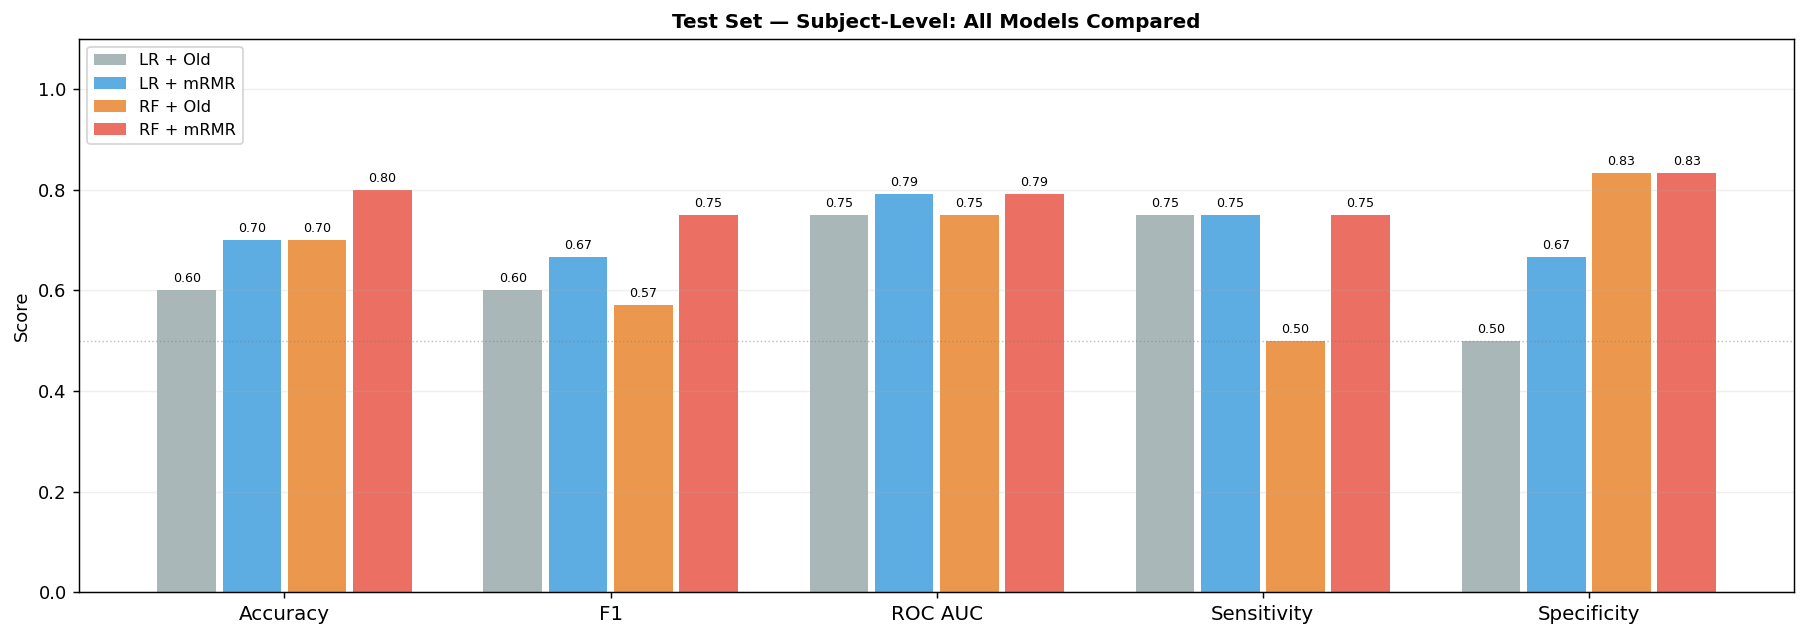

In [12]:
# ============================================================
# 4.2  Bar chart comparison (test set)
# ============================================================
test_comp = comp_df[comp_df['Split'] == 'Test'].copy()
metrics_plot = ['acc', 'f1', 'auc', 'sens', 'spec']
metric_labels = ['Accuracy', 'F1', 'ROC AUC', 'Sensitivity', 'Specificity']

fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(len(metrics_plot))
n_models = len(test_comp)
width = 0.8 / n_models

colors = ['#95A5A6', '#3498DB', '#E67E22', '#E74C3C']

for i, (_, row) in enumerate(test_comp.iterrows()):
    vals = [row[m] for m in metrics_plot]
    bars = ax.bar(x + i * width - (n_models - 1) * width / 2, vals,
                  width * 0.9, label=row['Model'], color=colors[i], alpha=0.8)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Test Set — Subject-Level: All Models Compared')
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.2)
ax.axhline(0.5, color='gray', ls=':', lw=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

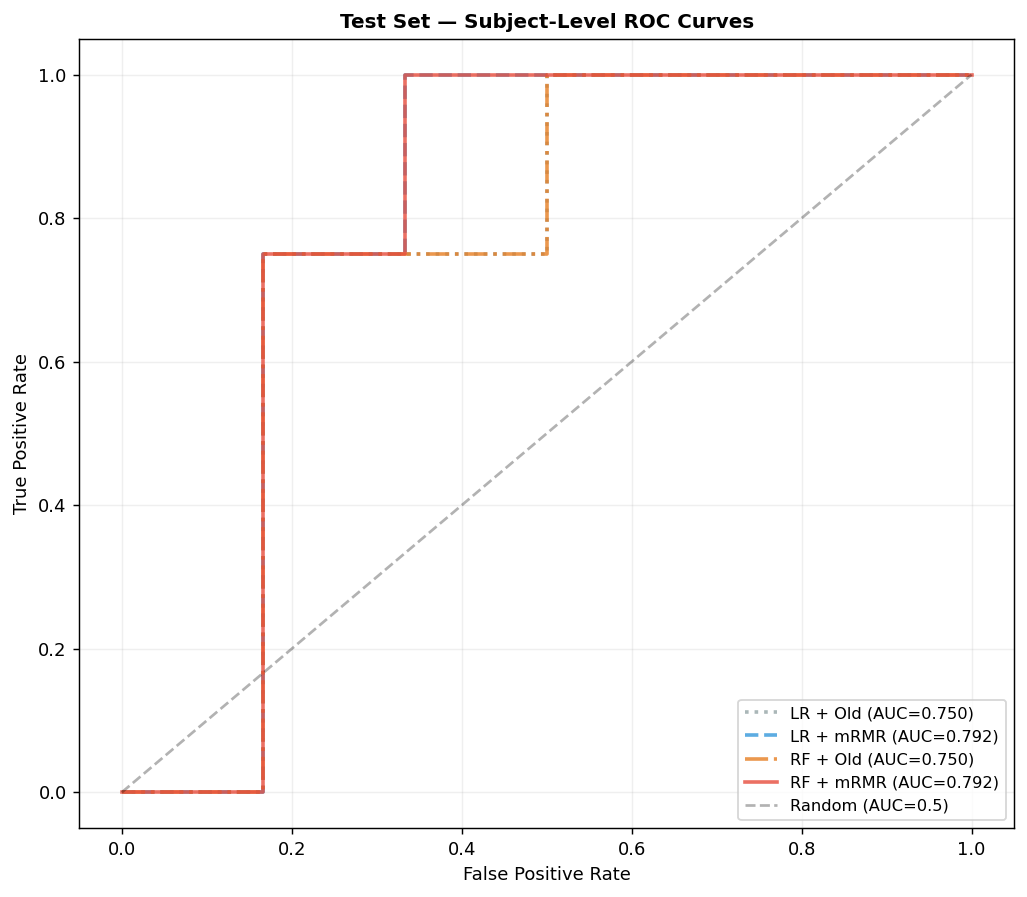

In [14]:
# ============================================================
# 4.3  ROC curves (test set, subject-level probabilities)
# ============================================================
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 7))

linestyles = [':', '--', '-.', '-']
colors = ['#95A5A6', '#3498DB', '#E67E22', '#E74C3C']

for i, (model_name, subj) in enumerate(test_preds.items()):
    fpr, tpr, _ = roc_curve(subj['true_label'], subj['mean_prob'])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linestyle=linestyles[i], color=colors[i],
            linewidth=2, alpha=0.8, label=f'{model_name} (AUC={roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Test Set — Subject-Level ROC Curves')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('model_comparison_roc.png', dpi=150, bbox_inches='tight')
plt.show()

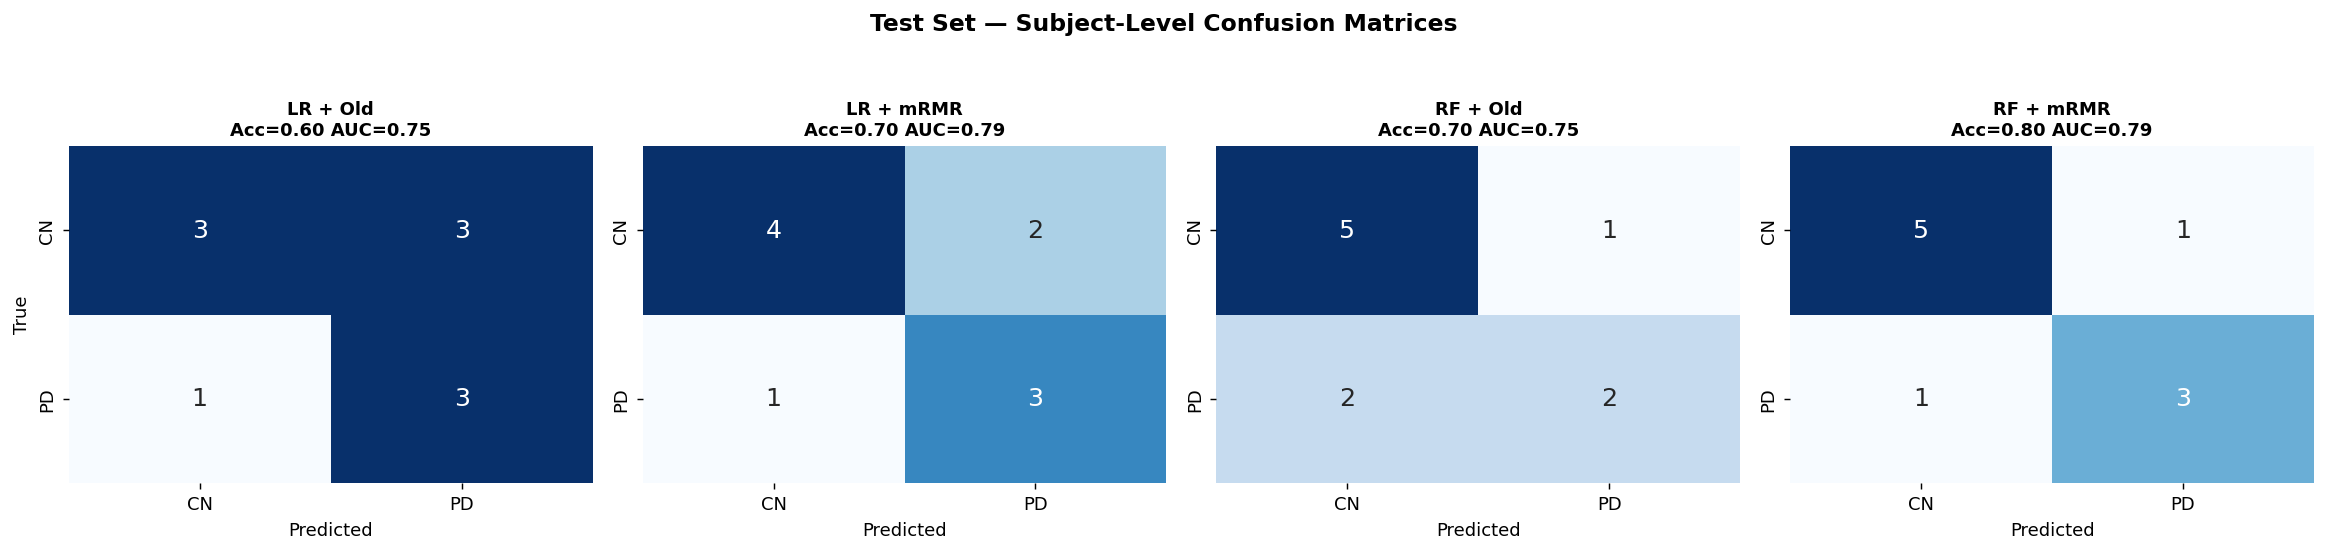

In [15]:
# ============================================================
# 4.4  Confusion matrices (test set, all 4 models)
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (model_name, subj) in zip(axes, test_preds.items()):
    cm = confusion_matrix(subj['true_label'], subj['vote_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['CN', 'PD'], yticklabels=['CN', 'PD'],
                cbar=False, annot_kws={'size': 14})
    acc = accuracy_score(subj['true_label'], subj['vote_pred'])
    auc = roc_auc_score(subj['true_label'], subj['mean_prob'])
    ax.set_title(f'{model_name}\nAcc={acc:.2f} AUC={auc:.2f}', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True' if ax == axes[0] else '')

plt.suptitle('Test Set — Subject-Level Confusion Matrices',
             fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('model_comparison_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5 — Random Forest feature importance

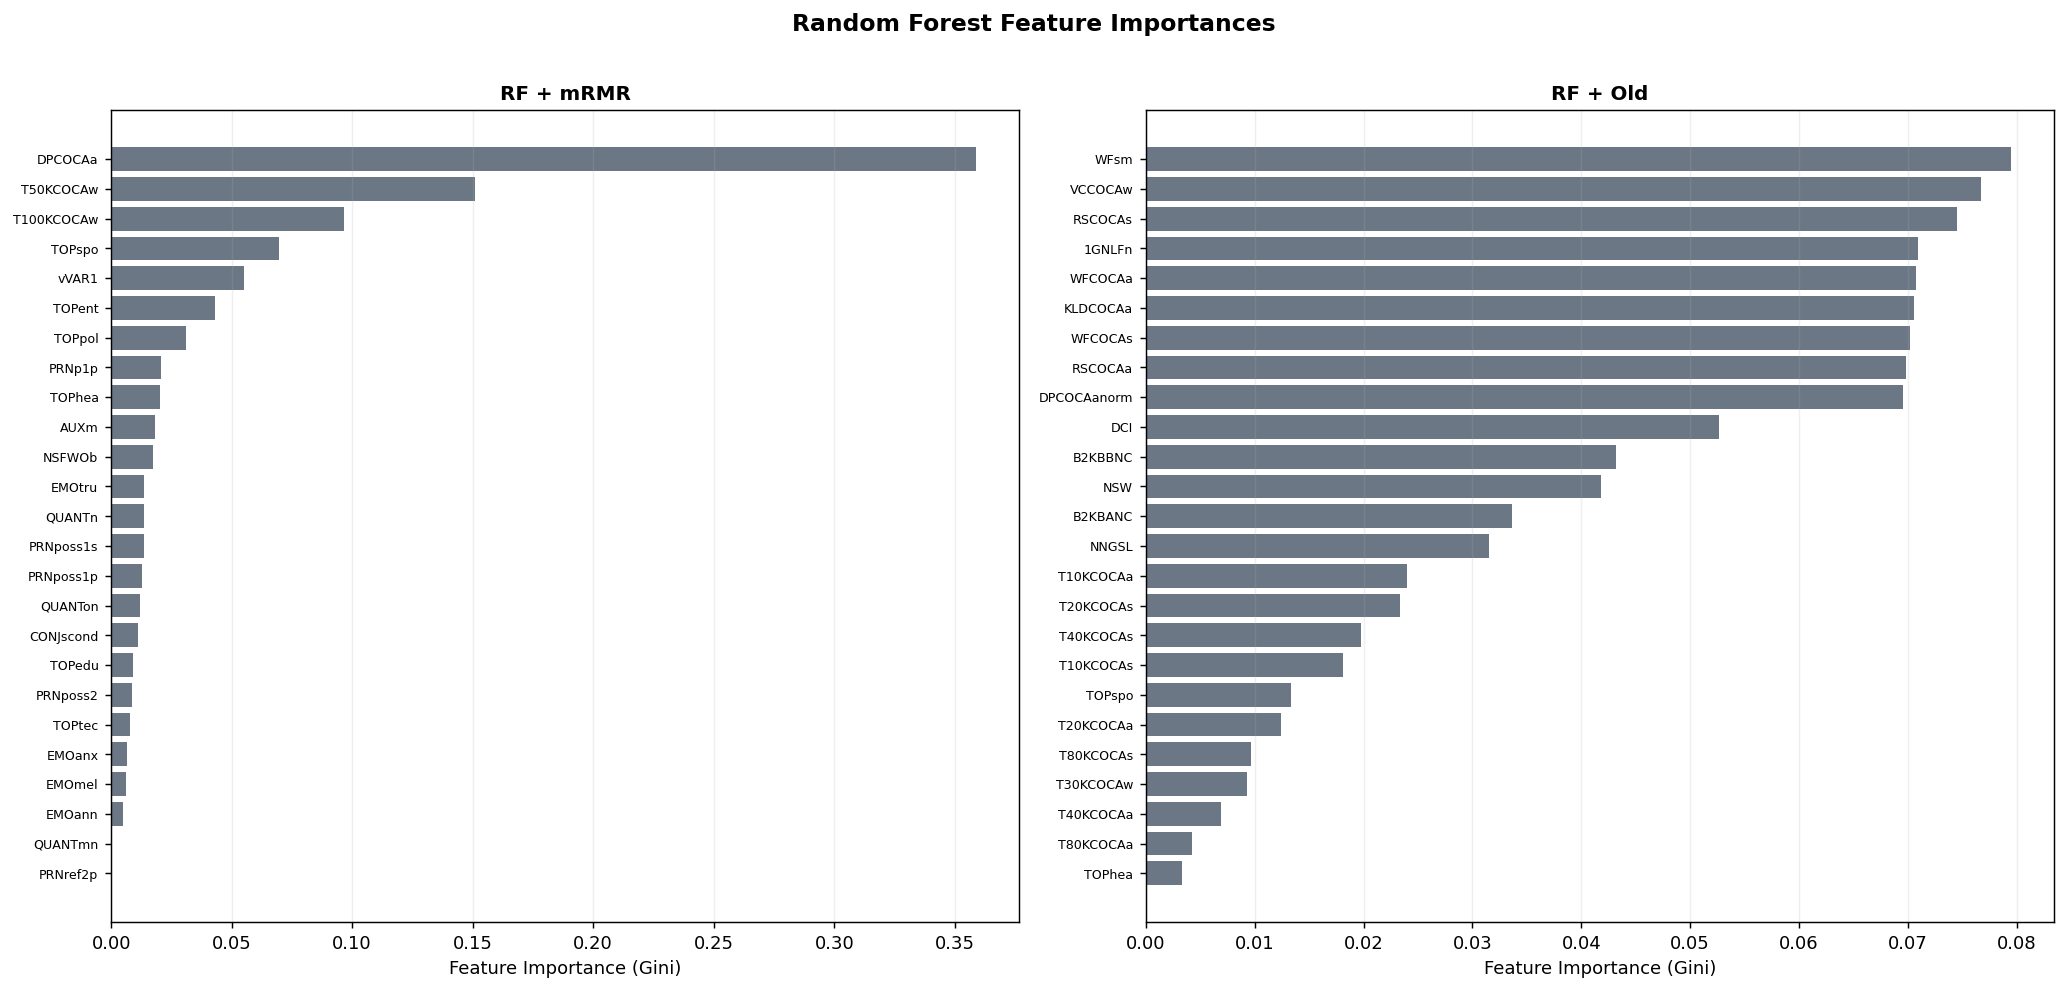

In [16]:
# ============================================================
# 5.  Feature importance from RF models
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(mrmr_features) * 0.3)))

for ax, model, features, title in [
    (axes[0], rf_mrmr, mrmr_features, 'RF + mRMR'),
    (axes[1], rf_old, old_features, 'RF + Old'),
]:
    importances = model.feature_importances_
    sorted_idx = np.argsort(importances)[::-1]
    
    sorted_feats = [features[i] for i in sorted_idx]
    sorted_imps = importances[sorted_idx]
    
    ax.barh(range(len(sorted_feats)), sorted_imps, color='#2C3E50', alpha=0.7)
    ax.set_yticks(range(len(sorted_feats)))
    ax.set_yticklabels(sorted_feats, fontsize=7)
    ax.set_xlabel('Feature Importance (Gini)')
    ax.set_title(title)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.2)

plt.suptitle('Random Forest Feature Importances',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('rf_feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6 — Full dataset evaluation (all 100 subjects)

In [17]:
# ============================================================
# 6.  All subjects, all models
# ============================================================
print('FULL DATASET — ALL SUBJECTS (subject-level majority vote)')
print('=' * 70)

for model_name, model, features, scaler in models:
    subj, metrics = subject_eval(df, features, model, scaler)
    
    wrong = subj[subj['true_label'] != subj['vote_pred']]
    
    print(f'\n  {model_name}')
    print(f'    Acc={metrics["acc"]:.3f}  F1={metrics["f1"]:.3f}  '
          f'AUC={metrics["auc"]:.3f}  Sens={metrics["sens"]:.3f}  Spec={metrics["spec"]:.3f}')
    print(f'    Misclassified: {len(wrong)}/{len(subj)} subjects')
    if len(wrong) > 0:
        for _, row in wrong.sort_values('subject').iterrows():
            true = 'PD' if row['true_label'] == 1 else 'CN'
            split = 'train' if row['subject'] in train_subjects else \
                    'val' if row['subject'] in val_subjects else 'test'
            print(f'      ✗ {row["subject"]:<10s} true={true}  P(PD)={row["mean_prob"]:.3f}  '
                  f'n_utt={row["n_utt"]:.0f}  [{split}]')

FULL DATASET — ALL SUBJECTS (subject-level majority vote)

  LR + Old
    Acc=0.580  F1=0.618  AUC=0.797  Sens=0.850  Spec=0.400
    Misclassified: 42/100 subjects
      ✗ cn_01      true=CN  P(PD)=0.519  n_utt=1568  [train]
      ✗ cn_02      true=CN  P(PD)=0.513  n_utt=2520  [train]
      ✗ cn_05      true=CN  P(PD)=0.548  n_utt=1514  [train]
      ✗ cn_06      true=CN  P(PD)=0.512  n_utt=1144  [train]
      ✗ cn_09      true=CN  P(PD)=0.507  n_utt=2210  [train]
      ✗ cn_10      true=CN  P(PD)=0.505  n_utt=1387  [train]
      ✗ cn_13      true=CN  P(PD)=0.501  n_utt=594  [train]
      ✗ cn_14      true=CN  P(PD)=0.509  n_utt=1603  [train]
      ✗ cn_15      true=CN  P(PD)=0.514  n_utt=2348  [test]
      ✗ cn_17      true=CN  P(PD)=0.506  n_utt=2661  [train]
      ✗ cn_19      true=CN  P(PD)=0.510  n_utt=1587  [val]
      ✗ cn_20      true=CN  P(PD)=0.515  n_utt=643  [train]
      ✗ cn_21      true=CN  P(PD)=0.510  n_utt=882  [val]
      ✗ cn_22      true=CN  P(PD)=0.503  n_utt=1588

In [18]:
# ============================================================
# 7.  Summary table for presentation
# ============================================================
print('\n\nFINAL SUMMARY TABLE (Test Set, Subject-Level)')
print('╔═══════════════╤═════════╤════════╤═════════╤═══════════════╤═══════════════╗')
print('║ Model         │ Acc     │ F1     │ AUC     │ Sensitivity   │ Specificity   ║')
print('╠═══════════════╪═════════╪════════╪═════════╪═══════════════╪═══════════════╣')

for _, row in comp_df[comp_df['Split'] == 'Test'].iterrows():
    print(f'║ {row["Model"]:<13s} │ {row["acc"]:>5.3f}   │ {row["f1"]:>4.3f}  │ '
          f'{row["auc"]:>5.3f}   │ {row["sens"]:>11.3f}   │ {row["spec"]:>11.3f}   ║')

print('╚═══════════════╧═════════╧════════╧═════════╧═══════════════╧═══════════════╝')
print('\nHigher is better for all metrics. AUC > 0.7 is acceptable, > 0.8 is good, > 0.9 is excellent.')



FINAL SUMMARY TABLE (Test Set, Subject-Level)
╔═══════════════╤═════════╤════════╤═════════╤═══════════════╤═══════════════╗
║ Model         │ Acc     │ F1     │ AUC     │ Sensitivity   │ Specificity   ║
╠═══════════════╪═════════╪════════╪═════════╪═══════════════╪═══════════════╣
║ LR + Old      │ 0.600   │ 0.600  │ 0.750   │       0.750   │       0.500   ║
║ LR + mRMR     │ 0.700   │ 0.667  │ 0.792   │       0.750   │       0.667   ║
║ RF + Old      │ 0.700   │ 0.571  │ 0.750   │       0.500   │       0.833   ║
║ RF + mRMR     │ 0.800   │ 0.750  │ 0.792   │       0.750   │       0.833   ║
╚═══════════════╧═════════╧════════╧═════════╧═══════════════╧═══════════════╝

Higher is better for all metrics. AUC > 0.7 is acceptable, > 0.8 is good, > 0.9 is excellent.
